In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print ("libraries imported successfully")

libraries imported successfully


In [2]:
# Membaca file CSV
order_items_df = pd.read_csv('data/olist_order_items_dataset.csv')
products_df = pd.read_csv('data/olist_products_dataset.csv')
translation_df = pd.read_csv('data/product_category_name_translation.csv')

print("Data successfully loaded!")

Data successfully loaded!


In [3]:
# 1. Gabungkan order_items dengan products
merged_df = pd.merge(order_items_df, products_df, on='product_id', how='left')

# 2. Tambahkan terjemahan bahasa Inggris untuk nama kategori
merged_df = pd.merge(merged_df, translation_df, on='product_category_name', how='left')

# Tampilkan 5 baris pertama untuk memastikan data sudah menyatu
merged_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [4]:
# Mengecek jumlah data yang kosong di setiap kolom
merged_df.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name            1603
product_name_lenght              1603
product_description_lenght       1603
product_photos_qty               1603
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
product_category_name_english    1627
dtype: int64

In [5]:
# 1. Mengisi nilai yang kosong (NaN) dengan kata 'Unknown'
merged_df['product_category_name_english'] = merged_df['product_category_name_english'].fillna('Unknown')

# Cek kembali untuk memastikan tidak ada data kosong di kolom kategori
print("Sisa data kosong di kategori:", merged_df['product_category_name_english'].isnull().sum())
print("-" * 30)

# 2. Menghitung Total Pendapatan (Revenue) per Kategori Produk
# Kita mengelompokkan data (groupby) berdasarkan kategori, lalu menjumlahkan (sum) kolom price
category_revenue = merged_df.groupby('product_category_name_english')['price'].sum().reset_index()

# 3. Mengurutkan data dari pendapatan tertinggi (Top Performers)
category_revenue = category_revenue.sort_values(by='price', ascending=False)

# Menampilkan 10 Kategori dengan Pendapatan Tertinggi
category_revenue.head(10)

Sisa data kosong di kategori: 0
------------------------------


,product_category_name_english,price
44,health_beauty,1258681.34
71,watches_gifts,1205005.68
8,bed_bath_table,1036988.68
66,sports_leisure,988048.97
16,computers_accessories,911954.32
40,furniture_decor,729762.49
21,cool_stuff,635290.85
50,housewares,632248.66
6,auto,592720.11
43,garden_tools,485256.46


C:\Users\sagita pra kosa\AppData\Local\Temp\ipykernel_8004\1328518936.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


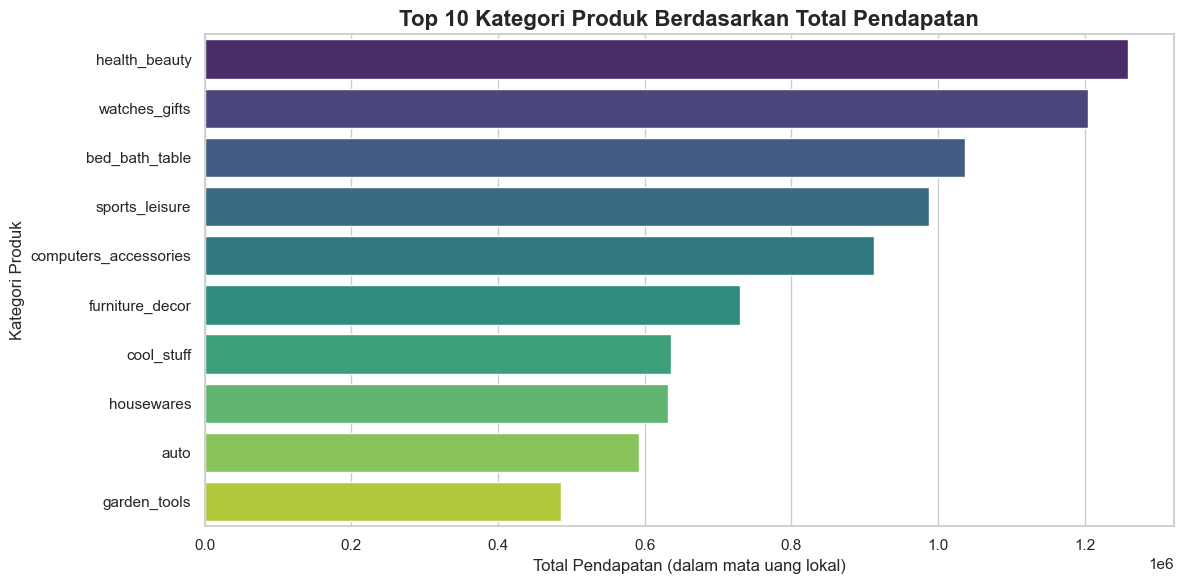

In [6]:
# 1. Mengambil Top 10 kategori saja agar grafik tidak terlalu padat
top_10_revenue = category_revenue.head(10)

# 2. Mengatur ukuran kanvas grafik (lebar, tinggi)
plt.figure(figsize=(12, 6))

# 3. Membuat Bar Chart Horizontal
sns.barplot(
    x='price', 
    y='product_category_name_english', 
    data=top_10_revenue, 
    palette='viridis' # Skema warna gradasi agar terlihat profesional
)

# 4. Menambahkan Judul dan Label yang informatif
plt.title('Top 10 Kategori Produk Berdasarkan Total Pendapatan', fontsize=16, fontweight='bold')
plt.xlabel('Total Pendapatan (dalam mata uang lokal)', fontsize=12)
plt.ylabel('Kategori Produk', fontsize=12)

# 5. Merapikan tata letak dan menampilkan grafik
plt.tight_layout()
plt.show()

In [8]:
# Menyimpan data yang sudah digabung dan dibersihkan ke dalam file CSV baru
# index=False digunakan agar nomor baris tidak ikut tersimpan sebagai kolom baru
merged_df.to_csv('data/cleaned_ecommerce_data.csv', index=False)

print("Data bersih berhasil disimpan sebagai 'cleaned_ecommerce_data.csv'")

Data bersih berhasil disimpan sebagai 'cleaned_ecommerce_data.csv'
